### Описательные статистики числовых признаков

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
SEED = 42
np.random.seed(SEED)

In [24]:
X = pd.read_csv('data/data.csv', sep='$')
X

,time_s,lw_x,lw_y,lw_z,lh_x,lh_y,lh_z,la_x,la_y,la_z,ra_x,ra_y,ra_z,subj_id,gender,age,height_in,weight_lbs,race,right_handed
0,1059.33,-0.941,0.168,0.215,-0.320,-0.789,-0.469,0.719,0.664,0.176,-0.809,0.570,0.219,id82b9735c,male,43,NaN,185.0,caucasian,1
1,2192.85,-0.508,0.105,-0.879,-0.461,-0.738,-0.445,0.125,0.980,0.012,-0.840,0.586,0.078,idfc5f05e4,female,30,65.0,110.0,caucasian,1
2,2187.52,-0.641,-0.012,-0.840,-0.355,-0.777,-0.449,0.012,1.016,0.047,-0.746,0.719,0.039,id00b70b13,female,45,69.0,212.0,caucasian,1
3,1785.40,-0.973,0.152,0.102,-0.313,-0.816,-0.461,-0.125,1.047,0.012,-0.766,NaN,0.125,id00b70b13,female,45,69.0,212.0,caucasian,1
4,2170.49,-0.578,0.063,-0.840,-0.449,-0.738,-0.449,0.121,0.996,0.023,-0.840,0.539,0.164,id9603e9c3,male,30,72.0,198.0,asian,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,588.42,-1.031,NaN,1.121,-0.055,-0.715,-0.223,0.203,NaN,0.070,1.191,0.801,-0.031,idff99de96,female,33,66.0,138.0,asian,1
3996,615.92,0.238,-0.961,0.457,-0.020,0.297,NaN,-0.672,1.719,0.309,-0.582,-0.641,0.172,idc735fc09,male,29,76.0,250.0,caucasian,1
3997,310.61,-0.121,-1.094,-0.391,0.352,NaN,-0.277,-0.664,1.027,0.148,0.328,0.773,0.117,idc735fc09,male,29,76.0,250.0,caucasian,1
3998,589.76,0.078,-0.660,-0.621,1.051,-2.160,0.242,1.313,0.535,-0.215,5.543,-0.426,0.727,id9603e9c3,male,30,72.0,NaN,asian,1


In [25]:
y = pd.read_csv('data/labels.csv')
y

,activity
0,driving
1,driving
2,driving
3,driving
4,driving
...,...
3995,ascending stairs
3996,ascending stairs
3997,ascending stairs
3998,ascending stairs


# Модуль А: Предобработка данных

## 1.1. Загрузка и анализ исходного набора данных


In [26]:
# Объединяем данные с метками для удобства анализа
df = pd.concat([X, y], axis=1)
df.drop_duplicates()
print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:")
print(df.dtypes)
print(f"\nИнформация о датасете:")
df.info()

Размер датасета: (4000, 21)

Типы данных:
time_s          float64
lw_x            float64
lw_y            float64
lw_z            float64
lh_x            float64
lh_y            float64
lh_z            float64
la_x            float64
la_y            float64
la_z            float64
ra_x            float64
ra_y            float64
ra_z            float64
subj_id          object
gender           object
age               int64
height_in       float64
weight_lbs      float64
race             object
right_handed      int64
activity         object
dtype: object

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time_s        4000 non-null   float64
 1   lw_x          3783 non-null   float64
 2   lw_y          3802 non-null   float64
 3   lw_z          3819 non-null   float64
 4   lh_x          3774 non-null   float64
 5   lh_

In [27]:
# Анализ распределения классов активности
print("Распределение типов активности:")
print(df['activity'].value_counts())
print(f"Уникальные типы активности: {df['activity'].unique()}")

Распределение типов активности:
activity
driving               1000
non-study activity    1000
walking               1000
descending stairs      500
ascending stairs       500
Name: count, dtype: int64
Уникальные типы активности: ['driving' 'non-study activity' 'walking' 'descending stairs'
 'ascending stairs']


In [28]:
df.nunique()

time_s          3958
lw_x             575
lw_y             785
lw_z             446
lh_x             435
lh_y             588
lh_z             314
la_x             902
la_y             781
la_z             510
ra_x             895
ra_y             845
ra_z             607
subj_id           32
gender             2
age               21
height_in         15
weight_lbs        28
race               3
right_handed       2
activity           5
dtype: int64

Имеем, что половина признаков имеет небольшой процент пропущенных значений. Признак `time_s` - время с момента запуска устройства (секунды [с]), значит он не несет никакой информативности для классификации активности, аналогично ситуация с `subj_id` - идентификатор участника, т.к. тоже не несет информации, ведь не важно какой идентификатор был у человека, у которого оценивали физическую активность.

**Итоговый набор полей:** `lw_x`, `lw_y`, `lw_z`, `lh_x`, `lh_y`, `lh_z`, `la_x`, `la_y`, `la_z`, `ra_x`, `ra_y`, `ra_z`, `age`, `height_in`, `weight_lbs`, `right_handed`, `gender`, `race`, `activity`

## 1.2. Создание структуры данных для итогового набора полей

**Итоговый набор полей:** `lw_x`, `lw_y`, `lw_z`, `lh_x`, `lh_y`, `lh_z`, `la_x`, `la_y`, `la_z`, `ra_x`, `ra_y`, `ra_z`, `age`, `height_in`, `weight_lbs`, `right_handed`, `gender`, `race`, `activity`

In [29]:
# Определяем группы признаков
sensor_cols = ['lw_x', 'lw_y', 'lw_z', 'lh_x', 'lh_y', 'lh_z', 
               'la_x', 'la_y', 'la_z', 'ra_x', 'ra_y', 'ra_z']
demographic_numeric_cols = ['age', 'height_in', 'weight_lbs', 'right_handed']
categorical_cols = ['gender', 'race']
id_col = 'subj_id'
target_col = 'activity'

# Все числовые признаки (для анализа и обработки)
numeric_cols = sensor_cols + demographic_numeric_cols

# Столбцы для удаления
cols_to_drop = ['time_s', 'subj_id']

print(f"Сенсорные признаки ({len(sensor_cols)}): {sensor_cols}")
print(f"Демографические числовые ({len(demographic_numeric_cols)}): {demographic_numeric_cols}")
print(f"Категориальные ({len(categorical_cols)}): {categorical_cols}")
print(f"Столбцы для удаления: {cols_to_drop}")
print(f'Целевая переменная: {target_col}')

Сенсорные признаки (12): ['lw_x', 'lw_y', 'lw_z', 'lh_x', 'lh_y', 'lh_z', 'la_x', 'la_y', 'la_z', 'ra_x', 'ra_y', 'ra_z']
Демографические числовые (4): ['age', 'height_in', 'weight_lbs', 'right_handed']
Категориальные (2): ['gender', 'race']
Столбцы для удаления: ['time_s', 'subj_id']
Целевая переменная: activity


In [30]:
df = df.drop(columns=cols_to_drop)
df.head()

,lw_x,lw_y,lw_z,lh_x,lh_y,lh_z,la_x,la_y,la_z,ra_x,ra_y,ra_z,gender,age,height_in,weight_lbs,race,right_handed,activity
0,-0.941,0.168,0.215,-0.320,-0.789,-0.469,0.719,0.664,0.176,-0.809,0.570,0.219,male,43,NaN,185.0,caucasian,1,driving
1,-0.508,0.105,-0.879,-0.461,-0.738,-0.445,0.125,0.980,0.012,-0.840,0.586,0.078,female,30,65.0,110.0,caucasian,1,driving
2,-0.641,-0.012,-0.840,-0.355,-0.777,-0.449,0.012,1.016,0.047,-0.746,0.719,0.039,female,45,69.0,212.0,caucasian,1,driving
3,-0.973,0.152,0.102,-0.313,-0.816,-0.461,-0.125,1.047,0.012,-0.766,NaN,0.125,female,45,69.0,212.0,caucasian,1,driving
4,-0.578,0.063,-0.840,-0.449,-0.738,-0.449,0.121,0.996,0.023,-0.840,0.539,0.164,male,30,72.0,198.0,asian,1,driving


## 1.3. Разбиение набора данных на обучающую и тестовую выборки

**Выбор: стратифицированное разбиение 85/15**

**Обоснование:**
1. **Стратификация по целевой переменной** - сохраняет пропорции классов в обеих выборках, что критично при несбалансированных данных
2. **Соотношение 85/15** - изначальная выборка небольшая, всего 4000 объектов, поэтому оптимальным отношением будет 85/15, чтобы было достаточно данных для обучения, а 15% точно хватит на тесты

In [31]:
# Разделяем на признаки (X) и целевую переменную (y)
X = df.drop(columns=[target_col])
y = df[target_col]
X

,lw_x,lw_y,lw_z,lh_x,lh_y,lh_z,la_x,la_y,la_z,ra_x,ra_y,ra_z,gender,age,height_in,weight_lbs,race,right_handed
0,-0.941,0.168,0.215,-0.320,-0.789,-0.469,0.719,0.664,0.176,-0.809,0.570,0.219,male,43,NaN,185.0,caucasian,1
1,-0.508,0.105,-0.879,-0.461,-0.738,-0.445,0.125,0.980,0.012,-0.840,0.586,0.078,female,30,65.0,110.0,caucasian,1
2,-0.641,-0.012,-0.840,-0.355,-0.777,-0.449,0.012,1.016,0.047,-0.746,0.719,0.039,female,45,69.0,212.0,caucasian,1
3,-0.973,0.152,0.102,-0.313,-0.816,-0.461,-0.125,1.047,0.012,-0.766,NaN,0.125,female,45,69.0,212.0,caucasian,1
4,-0.578,0.063,-0.840,-0.449,-0.738,-0.449,0.121,0.996,0.023,-0.840,0.539,0.164,male,30,72.0,198.0,asian,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,-1.031,NaN,1.121,-0.055,-0.715,-0.223,0.203,NaN,0.070,1.191,0.801,-0.031,female,33,66.0,138.0,asian,1
3996,0.238,-0.961,0.457,-0.020,0.297,NaN,-0.672,1.719,0.309,-0.582,-0.641,0.172,male,29,76.0,250.0,caucasian,1
3997,-0.121,-1.094,-0.391,0.352,NaN,-0.277,-0.664,1.027,0.148,0.328,0.773,0.117,male,29,76.0,250.0,caucasian,1
3998,0.078,-0.660,-0.621,1.051,-2.160,0.242,1.313,0.535,-0.215,5.543,-0.426,0.727,male,30,72.0,NaN,asian,1


In [32]:
y

0                driving
1                driving
2                driving
3                driving
4                driving
              ...       
3995    ascending stairs
3996    ascending stairs
3997    ascending stairs
3998    ascending stairs
3999    ascending stairs
Name: activity, Length: 4000, dtype: object

In [33]:
from sklearn.model_selection import train_test_split

# Разбиение на обучающую и тестовую выборки (80/20) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15, 
    random_state=SEED, 
    stratify=y
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (3400, 18), y_train: (3400,)
X_test: (600, 18), y_test: (600,)


## 1.4. Предобработка данных

### 1.4.1. Удаление записей с активностью "ascending stairs"

По условию задания необходимо удалить объекты с активностью "подъем по лестнице" (ascending stairs).

In [34]:
# Удаляем записи с активностью "ascending stairs" из обеих выборок
mask_train = y_train != 'ascending stairs'
mask_test = y_test != 'ascending stairs'

X_train = X_train[mask_train]
y_train = y_train[mask_train]
X_test = X_test[mask_test]
y_test = y_test[mask_test]

print(f"После удаления 'ascending stairs':")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"\nОставшиеся классы: {y_train.unique()}")

После удаления 'ascending stairs':
X_train: (2975, 18), y_train: (2975,)
X_test: (525, 18), y_test: (525,)

Оставшиеся классы: ['walking' 'driving' 'non-study activity' 'descending stairs']


### 1.4.2. Обработка пропущенных значений

**Выбор метода:** MICE (Multiple Imputation by Chained Equations) - IterativeImputer

**Обоснование:**
- MICE учитывает взаимосвязи между признаками при заполнении пропусков
- Итеративно строит регрессионные модели для предсказания пропущенных значений
- Более точный метод по сравнению с простым заполнением средним/медианой
- Хорошо подходит для данных с множественными пропусками в разных столбцах

In [35]:
# Анализ пропусков в обучающей выборке
print("Пропущенные значения в X_train:")
missing_train = X_train.isnull().sum()
print(missing_train[missing_train > 0])

Пропущенные значения в X_train:
lw_x          179
lw_y          137
lw_z          134
lh_x          169
lh_y          148
lh_z          137
la_x          151
la_y          161
la_z          134
ra_x          146
ra_y          154
ra_z          142
height_in     124
weight_lbs    146
dtype: int64


In [36]:
from scipy.stats import entropy

def visualize_numeric_before_after(before: pd.Series, after: pd.Series, bins: int = 30):
    """
    Визуализирует вещественный признак до и после обработки пропущенных значений
    и выводит KL-дивергенцию над графиками.
    """
    before_vals = before.dropna().values
    after_vals = after.dropna().values
    
    combined_vals = np.concatenate([before_vals, after_vals])
    hist_range = (np.min(combined_vals), np.max(combined_vals))
    
    hist_before, bin_edges = np.histogram(before_vals, bins=bins, range=hist_range, density=True)
    hist_after, _ = np.histogram(after_vals, bins=bin_edges, density=True)
    
    epsilon = 1e-10
    hist_before = hist_before + epsilon
    hist_after = hist_after + epsilon
    hist_before = hist_before / hist_before.sum()
    hist_after = hist_after / hist_after.sum()
    
    kl = entropy(hist_before, hist_after)
    
    plt.figure(figsize=(14, 5))
    plt.suptitle(f'KL-дивергенция: {kl:.4f}', fontsize=16)
    
    plt.subplot(1, 2, 1)
    sns.histplot(before_vals, kde=True, color='skyblue', bins=bins)
    plt.title(f'До обработки пропусков (n={len(before_vals)})')
    plt.xlabel(before.name)
    plt.ylabel('Плотность')
    
    plt.subplot(1, 2, 2)
    sns.histplot(after_vals, kde=True, color='salmon', bins=bins)
    plt.title(f'После обработки пропусков (n={len(after_vals)})')
    plt.xlabel(after.name)
    plt.ylabel('Плотность')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [37]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Сохраняем копию до обработки для визуализации
X_train_before = X_train.copy()
X_test_before = X_test.copy()

# Применяем MICE (IterativeImputer)
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=SEED,
    initial_strategy='median'
)

# Обучаем на train, применяем к обоим
X_train[numeric_cols] = mice_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = mice_imputer.transform(X_test[numeric_cols])

print("После заполнения пропусков методом MICE:")
print(f"Пропусков в X_train: {X_train[numeric_cols].isnull().sum().sum()}")
print(f"Пропусков в X_test: {X_test[numeric_cols].isnull().sum().sum()}")

После заполнения пропусков методом MICE:
Пропусков в X_train: 0
Пропусков в X_test: 0


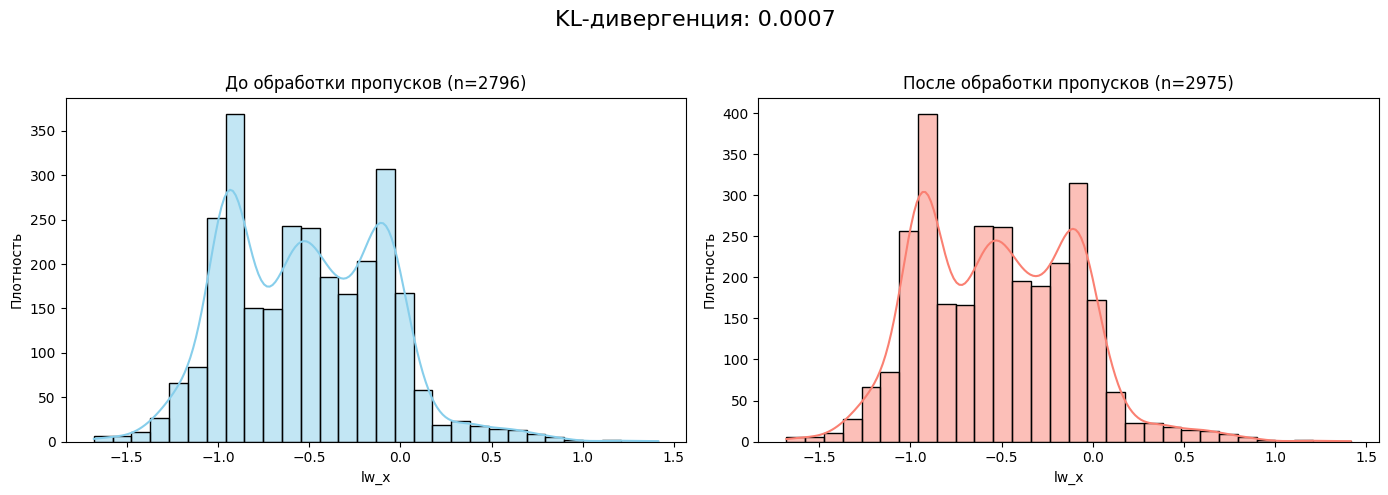

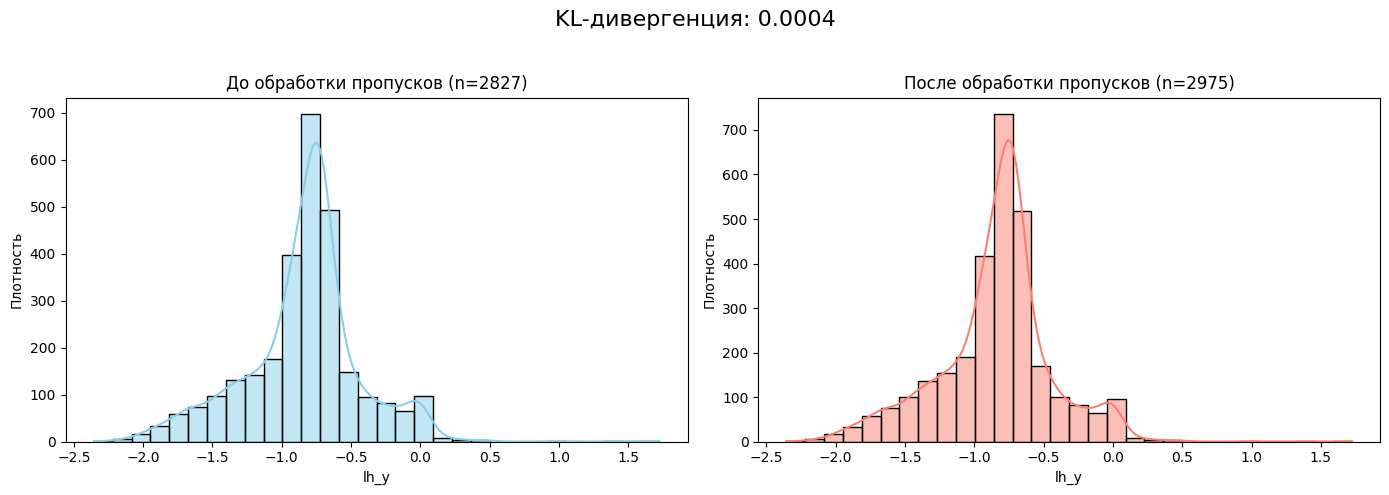

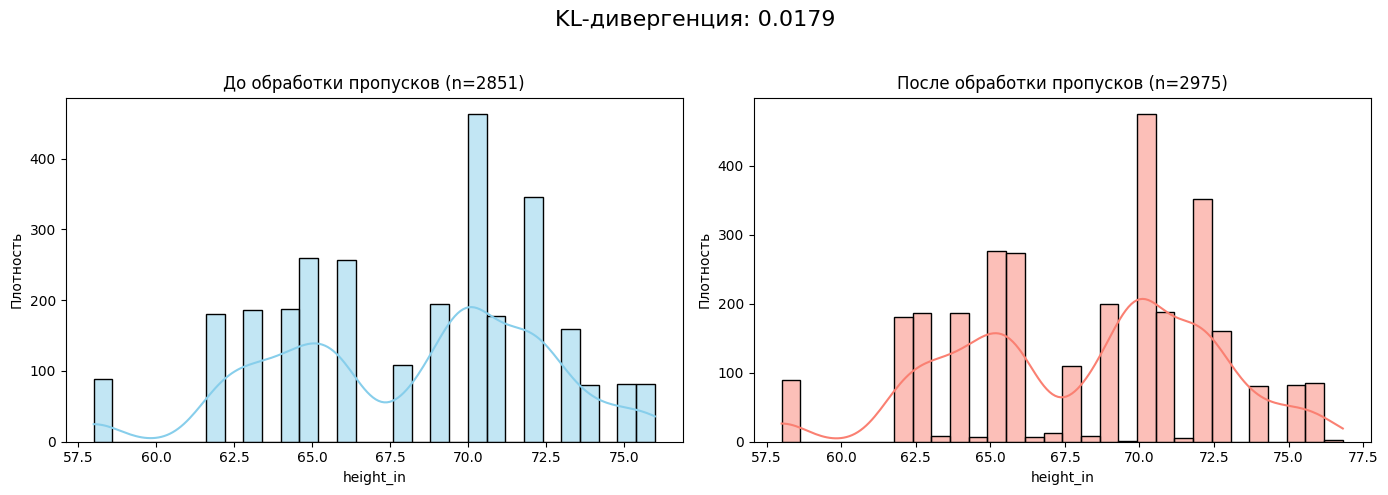

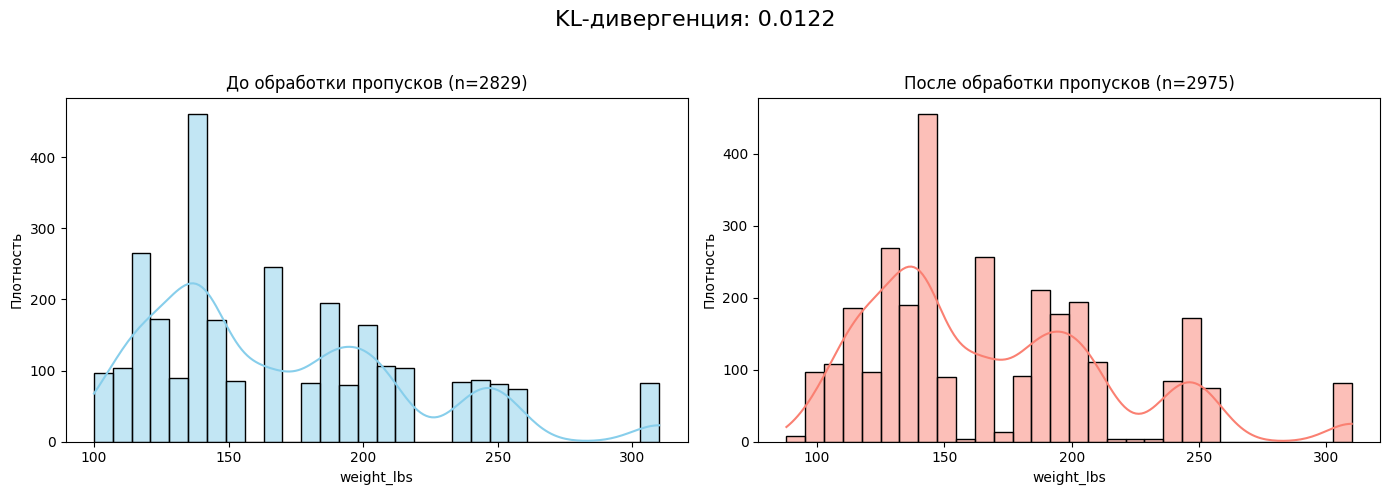

In [38]:
# Визуализация изменений после MICE для нескольких признаков
cols_to_visualize = ['lw_x', 'lh_y', 'height_in', 'weight_lbs']
for col in cols_to_visualize:
    visualize_numeric_before_after(X_train_before[col], X_train[col])

Видим, что KL-дивергенция довольная низкая, распределение практически не изменилось, следовательно MICE отлично отработал.

### 1.4.3. Анализ и обработка выбросов

**Методы:**
1. **IQR** (межквартильный размах) - выбросы за пределами [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
2. **Robust Z-score** - выбросы с |z| > 3, где z = (x - median) / MAD

**Стратегия:** Удаляем только те строки, которые являются выбросами по ОБОИМ методам (пересечение)

**Обоснование:**
- Комбинация двух методов повышает надежность обнаружения выбросов
- Удаление только пересечения - консервативный подход, минимизирует потерю данных
- Robust Z-score устойчив к выбросам (использует медиану и MAD вместо среднего и std)

In [39]:
from scipy.stats import median_abs_deviation

def get_iqr_outliers(df: pd.DataFrame, columns: list, k: float = 1.5) -> pd.Series:
    """Возвращает маску выбросов по методу IQR"""
    outlier_mask = pd.Series([False] * len(df), index=df.index)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR
        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_mask = outlier_mask | col_outliers
    
    return outlier_mask

def get_robust_zscore_outliers(df: pd.DataFrame, columns: list, threshold: float = 3.0) -> pd.Series:
    """Возвращает маску выбросов по методу Robust Z-score"""
    outlier_mask = pd.Series([False] * len(df), index=df.index)
    
    for col in columns:
        median = df[col].median()
        mad = median_abs_deviation(df[col], nan_policy='omit')
        # Избегаем деления на 0
        if mad == 0:
            mad = 1e-10
        robust_z = np.abs((df[col] - median) / (1.4826 * mad))  # 1.4826 - константа для нормального распределения
        col_outliers = robust_z > threshold
        outlier_mask = outlier_mask | col_outliers
    
    return outlier_mask

# Получаем маски выбросов обоими методами
iqr_outliers = get_iqr_outliers(X_train, sensor_cols)
robust_z_outliers = get_robust_zscore_outliers(X_train, sensor_cols)

# Пересечение - выбросы по ОБОИМ методам
intersection_outliers = iqr_outliers & robust_z_outliers

print(f"Выбросы по IQR: {iqr_outliers.sum()} ({iqr_outliers.sum()/len(X_train)*100:.2f}%)")
print(f"Выбросы по Robust Z-score: {robust_z_outliers.sum()} ({robust_z_outliers.sum()/len(X_train)*100:.2f}%)")
print(f"Пересечение (удаляем): {intersection_outliers.sum()} ({intersection_outliers.sum()/len(X_train)*100:.2f}%)")

Выбросы по IQR: 1413 (47.50%)
Выбросы по Robust Z-score: 1239 (41.65%)
Пересечение (удаляем): 1223 (41.11%)


In [40]:
# Удаляем выбросы из обучающей выборки
X_train = X_train[~intersection_outliers]
y_train = y_train[~intersection_outliers]

print(f"Размер после удаления выбросов:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"\nРаспределение классов после очистки:")
print(y_train.value_counts())

Размер после удаления выбросов:
X_train: (1752, 18), y_train: (1752,)

Распределение классов после очистки:
activity
driving               815
non-study activity    478
walking               343
descending stairs     116
Name: count, dtype: int64


### 1.4.4. Кодирование категориальных признаков

**Метод:** One-Hot Encoding для признаков `gender` и `race`

**Обоснование:**
- Категориальные признаки не имеют порядка, поэтому Label Encoding не подходит
- One-Hot Encoding создает бинарные признаки для каждой категории
- Подходит для небольшого числа уникальных значений (gender: 2, race: 3)

In [41]:
from sklearn.preprocessing import OneHotEncoder
import joblib

# One-Hot Encoding для категориальных признаков
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

# Обучаем на train
ohe.fit(X_train[categorical_cols])

# Получаем названия новых столбцов
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
print(f"Новые признаки после OHE: {ohe_feature_names}")

# Преобразуем train и test
X_train_ohe = pd.DataFrame(
    ohe.transform(X_train[categorical_cols]),
    columns=ohe_feature_names,
    index=X_train.index
)
X_test_ohe = pd.DataFrame(
    ohe.transform(X_test[categorical_cols]),
    columns=ohe_feature_names,
    index=X_test.index
)

# Удаляем исходные категориальные столбцы и добавляем закодированные
X_train = X_train.drop(columns=categorical_cols).join(X_train_ohe)
X_test = X_test.drop(columns=categorical_cols).join(X_test_ohe)

print(f"\nX_train shape после OHE: {X_train.shape}")
print(f"X_test shape после OHE: {X_test.shape}")
X_train.head()
joblib.dump(ohe, 'models/ohe.pkl')

Новые признаки после OHE: ['gender_male' 'race_black' 'race_caucasian']

X_train shape после OHE: (1752, 19)
X_test shape после OHE: (525, 19)


['models/ohe.pkl']

### 1.4.5. Стандартизация числовых признаков

**Метод:** StandardScaler (z-score нормализация)

**Обоснование:**
- Приводит все признаки к единому масштабу (среднее = 0, std = 1)
- Сохраняет форму распределения данных

In [42]:
from sklearn.preprocessing import StandardScaler

# Определяем числовые столбцы для стандартизации (без категориальных OHE)
cols_to_scale = sensor_cols + ['age', 'height_in', 'weight_lbs']

# Стандартизация
scaler = StandardScaler()

# Обучаем на train
scaler.fit(X_train[cols_to_scale])

# Применяем к обоим выборкам
X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train

,lw_x,lw_y,lw_z,lh_x,lh_y,lh_z,la_x,la_y,la_z,ra_x,ra_y,ra_z,age,height_in,weight_lbs,right_handed,gender_male,race_black,race_caucasian
677,-0.015628,0.612248,-1.934033,-1.368047,0.949356,-0.150964,1.114589,-0.845535,0.595285,-1.093915,-0.839682,0.998121,-0.567295,0.918109,0.458898,1.0,1.0,0.0,1.0
590,-0.990861,0.745459,0.329464,-0.744304,0.363559,-0.121213,0.060302,0.063235,-0.188356,-0.605380,-0.458963,0.034324,-1.706697,-1.255229,-1.407557,1.0,0.0,0.0,1.0
2624,1.263010,-0.627742,0.398779,2.604857,-1.368728,0.607686,-0.996955,0.381693,0.453483,0.248685,0.291751,0.707746,-0.909115,0.435145,0.424050,1.0,1.0,0.0,1.0
1530,-0.671202,0.479038,0.533383,1.262120,0.769433,1.358898,-0.797977,0.851613,-0.598834,0.593519,0.551910,-0.280764,-0.453355,-0.530783,-0.523333,0.0,0.0,1.0,0.0
2321,1.707283,-0.782210,0.510078,2.930555,-1.526665,1.827476,-0.789067,0.731220,-0.076407,0.350933,-0.151388,0.157888,-1.023056,0.918109,0.655632,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,0.057514,-0.671673,-0.500776,2.088656,0.903329,-1.341003,-1.448368,-0.375615,-2.173579,0.976445,0.294972,-0.836801,-1.136996,-0.530783,-0.986498,1.0,0.0,0.0,0.0
1712,-0.226929,-0.090121,-1.322277,1.477203,-1.689716,-0.240217,-0.509904,0.094304,0.132563,0.906276,0.274342,-0.663811,-1.023056,-0.772265,-1.197027,1.0,0.0,0.0,1.0
1850,0.956896,-0.700016,0.373161,1.068544,-1.225376,0.167577,-0.893011,0.016631,0.453483,-0.276585,-1.015975,-0.521713,1.711510,-1.496711,-0.039115,1.0,0.0,0.0,1.0
1889,1.200704,-0.522875,0.306159,0.816589,0.229662,0.139108,-0.741550,0.323438,0.154953,0.429122,-0.700898,-0.157200,1.027868,1.401073,3.013562,1.0,1.0,0.0,1.0


## 1.5. Итоговая проверка данных

In [43]:
print(f"\nРазмеры выборок:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test: {X_test.shape}, y_test: {y_test.shape}")

print(f"\nПропущенные значения:")
print(f"  X_train: {X_train.isnull().sum().sum()}")
print(f"  X_test: {X_test.isnull().sum().sum()}")

print(f"\nПризнаки ({X_train.shape[1]}):")
print(f"  {list(X_train.columns)}")

print(f"\nРаспределение классов (train):")
print(y_train.value_counts())

print(f"\nРаспределение классов (test):")
print(y_test.value_counts())


Размеры выборок:
  X_train: (1752, 19), y_train: (1752,)
  X_test: (525, 19), y_test: (525,)

Пропущенные значения:
  X_train: 0
  X_test: 0

Признаки (19):
  ['lw_x', 'lw_y', 'lw_z', 'lh_x', 'lh_y', 'lh_z', 'la_x', 'la_y', 'la_z', 'ra_x', 'ra_y', 'ra_z', 'age', 'height_in', 'weight_lbs', 'right_handed', 'gender_male', 'race_black', 'race_caucasian']

Распределение классов (train):
activity
driving               815
non-study activity    478
walking               343
descending stairs     116
Name: count, dtype: int64

Распределение классов (test):
activity
non-study activity    150
walking               150
driving               150
descending stairs      75
Name: count, dtype: int64


---

# Модуль B: Анализ зависимостей и классификация

## 2.1. Подбор алгоритмов выявления зависимостей параметров данных

### Алгоритмы для выявления зависимостей между входными признаками (не менее 3):

1. **Коэффициент корреляции Пирсона** - измеряет линейную зависимость между двумя непрерывными переменными. Значения от -1 до 1, где 0 означает отсутствие линейной связи.
   - *Обоснование*: Подходит для числовых признаков (сенсорные данные, демографические), позволяет быстро выявить линейные зависимости.

2. **Коэффициент корреляции Спирмена** - измеряет монотонную (не обязательно линейную) зависимость на основе рангов.
   - *Обоснование*: Более устойчив к выбросам и нелинейным зависимостям, что важно для данных с сенсоров.

3. **Коэффициент корреляции Кендалла (Tau)** - измеряет ординальную ассоциацию между переменными.
   - *Обоснование*: Эффективен для небольших выборок и данных с повторяющимися значениями (бинарные признаки после OHE).

4. **Взаимная информация (Mutual Information)** - измеряет количество информации, которое одна переменная содержит о другой.
   - *Обоснование*: Выявляет любые типы зависимостей (линейные и нелинейные), не требует предположений о распределении.

### Алгоритмы для выявления зависимостей между входными признаками и целевым (не менее 2):

1. **ANOVA F-statistic** - анализ дисперсии для оценки различий средних значений признака между классами.
   - *Обоснование*: Позволяет определить, какие числовые признаки статистически значимо различаются между классами активности.

2. **Mutual Information (для классификации)** - оценивает взаимную информацию между признаками и целевой переменной.
   - *Обоснование*: Выявляет нелинейные зависимости между признаками и целевым классом, что важно для сложных паттернов активности.

3. **Chi-squared test** - для категориальных признаков (gender, race после OHE).
   - *Обоснование*: Оценивает независимость между категориальными признаками и целевой переменной.

## 2.2. Оценка зависимостей между входными атрибутами

### 2.2.1. Корреляция Пирсона

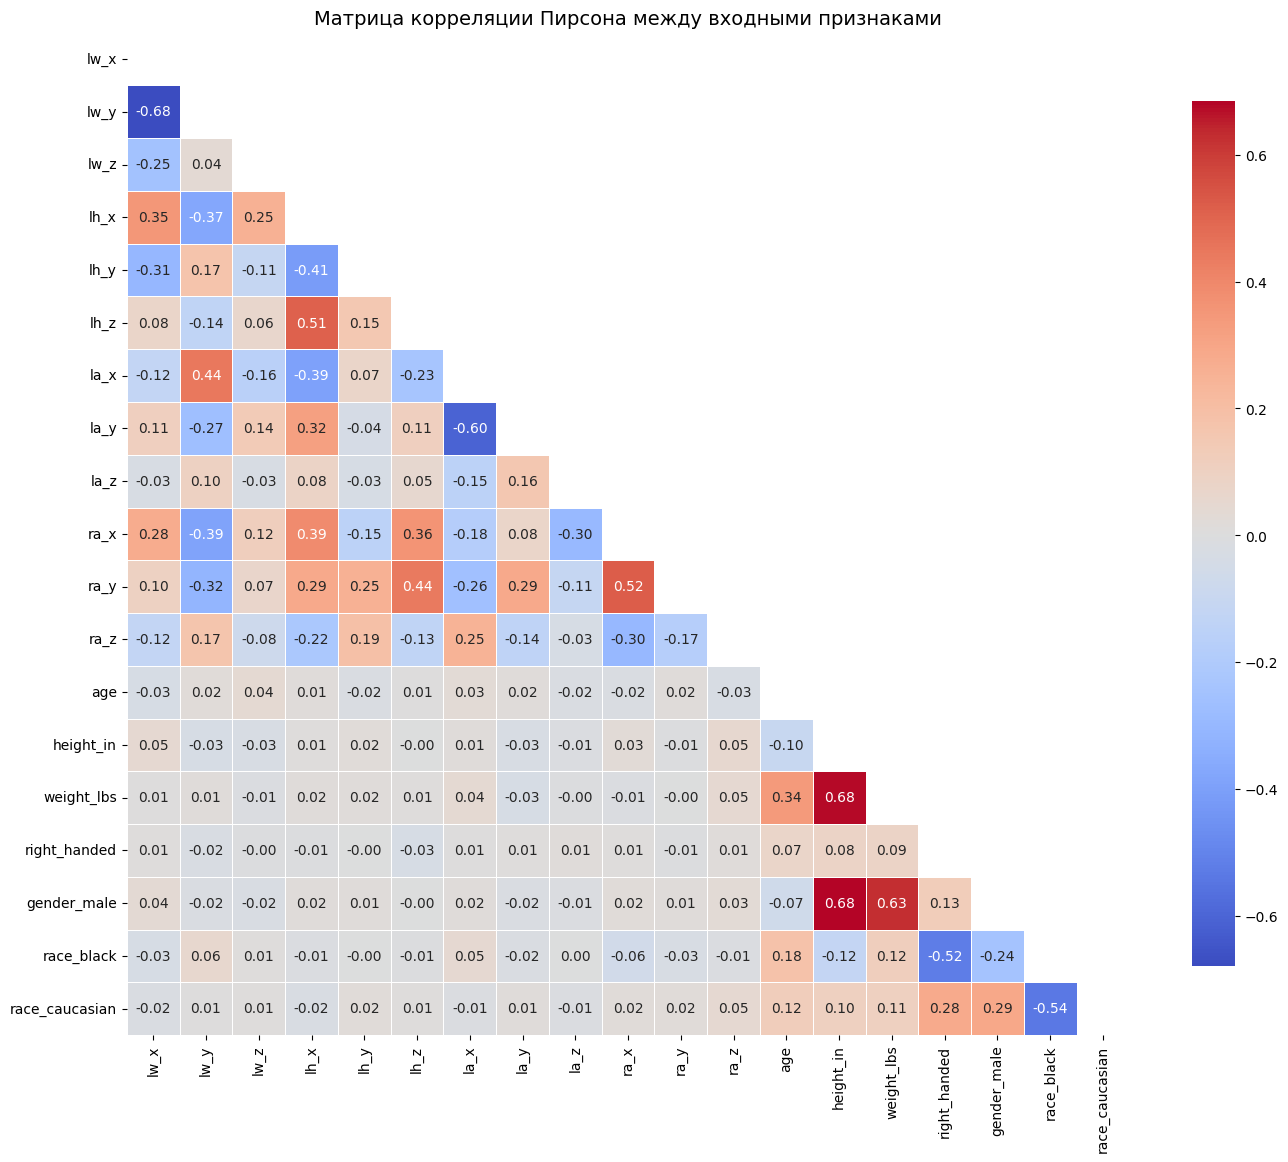

Топ-10 наиболее коррелированных пар признаков (Пирсон):
   feature_1      feature_2  correlation  abs_correlation
   height_in    gender_male     0.683795         0.683795
        lw_x           lw_y    -0.679122         0.679122
   height_in     weight_lbs     0.676979         0.676979
  weight_lbs    gender_male     0.628156         0.628156
        la_x           la_y    -0.604940         0.604940
  race_black race_caucasian    -0.537965         0.537965
right_handed     race_black    -0.521166         0.521166
        ra_x           ra_y     0.520088         0.520088
        lh_x           lh_z     0.508851         0.508851
        lw_y           la_x     0.444932         0.444932


In [44]:
# Корреляция Пирсона
pearson_corr = X_train.corr(method='pearson')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции Пирсона между входными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# Выведем наиболее сильные корреляции
corr_pairs = []
for i in range(len(pearson_corr.columns)):
    for j in range(i+1, len(pearson_corr.columns)):
        corr_pairs.append({
            'feature_1': pearson_corr.columns[i],
            'feature_2': pearson_corr.columns[j],
            'correlation': pearson_corr.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['abs_correlation'] = corr_df['correlation'].abs()
corr_df_sorted = corr_df.sort_values('abs_correlation', ascending=False)

print("Топ-10 наиболее коррелированных пар признаков (Пирсон):")
print(corr_df_sorted.head(10).to_string(index=False))

**Микровывод (Пирсон):**
- Корреляция Пирсона выявляет **линейные** зависимости между признаками
- Наиболее сильные корреляции наблюдаются между сенсорными признаками одной группы (например, между координатами одного датчика)
- `height_in` и `weight_lbs` имеют положительную корреляцию (~0.5-0.6), что физиологически обосновано
- Большинство признаков слабо коррелированы между собой, что говорит о низкой мультиколлинеарности

### 2.2.2. Корреляция Спирмена

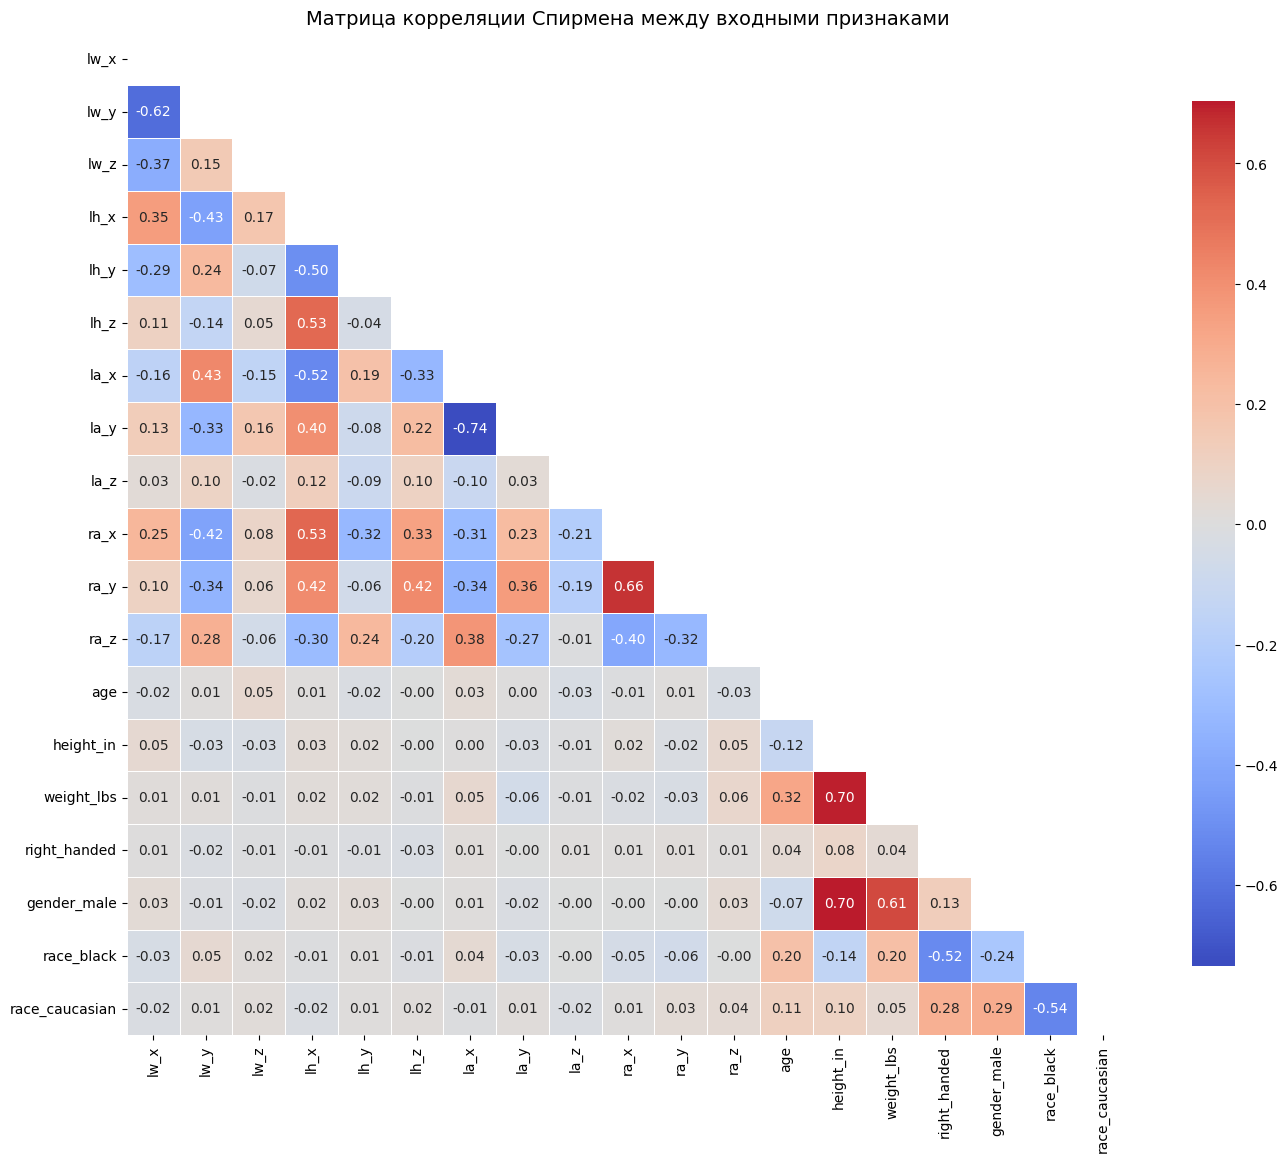

Топ-10 наиболее коррелированных пар признаков (Спирмен):
 feature_1      feature_2  correlation  abs_correlation
      la_x           la_y    -0.735044         0.735044
 height_in    gender_male     0.703004         0.703004
 height_in     weight_lbs     0.696885         0.696885
      ra_x           ra_y     0.663031         0.663031
      lw_x           lw_y    -0.622502         0.622502
weight_lbs    gender_male     0.610827         0.610827
race_black race_caucasian    -0.537965         0.537965
      lh_x           ra_x     0.531281         0.531281
      lh_x           lh_z     0.528608         0.528608
      lh_x           la_x    -0.524382         0.524382


In [45]:
# Корреляция Спирмена
spearman_corr = X_train.corr(method='spearman')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции Спирмена между входными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# Топ-10 по Спирмену
spearman_pairs = []
for i in range(len(spearman_corr.columns)):
    for j in range(i+1, len(spearman_corr.columns)):
        spearman_pairs.append({
            'feature_1': spearman_corr.columns[i],
            'feature_2': spearman_corr.columns[j],
            'correlation': spearman_corr.iloc[i, j]
        })

spearman_df = pd.DataFrame(spearman_pairs)
spearman_df['abs_correlation'] = spearman_df['correlation'].abs()
spearman_df_sorted = spearman_df.sort_values('abs_correlation', ascending=False)

print("Топ-10 наиболее коррелированных пар признаков (Спирмен):")
print(spearman_df_sorted.head(10).to_string(index=False))

**Микровывод (Спирмен):**
- Корреляция Спирмена выявляет **монотонные** (не обязательно линейные) зависимости на основе рангов
- Результаты схожи с Пирсоном, что указывает на преимущественно линейный характер зависимостей
- Метод более устойчив к выбросам, поэтому значения корреляций могут незначительно отличаться
- Ранговая корреляция подтверждает выводы о связи между `height_in` и `weight_lbs`

### 2.2.3. Корреляция Кендалла

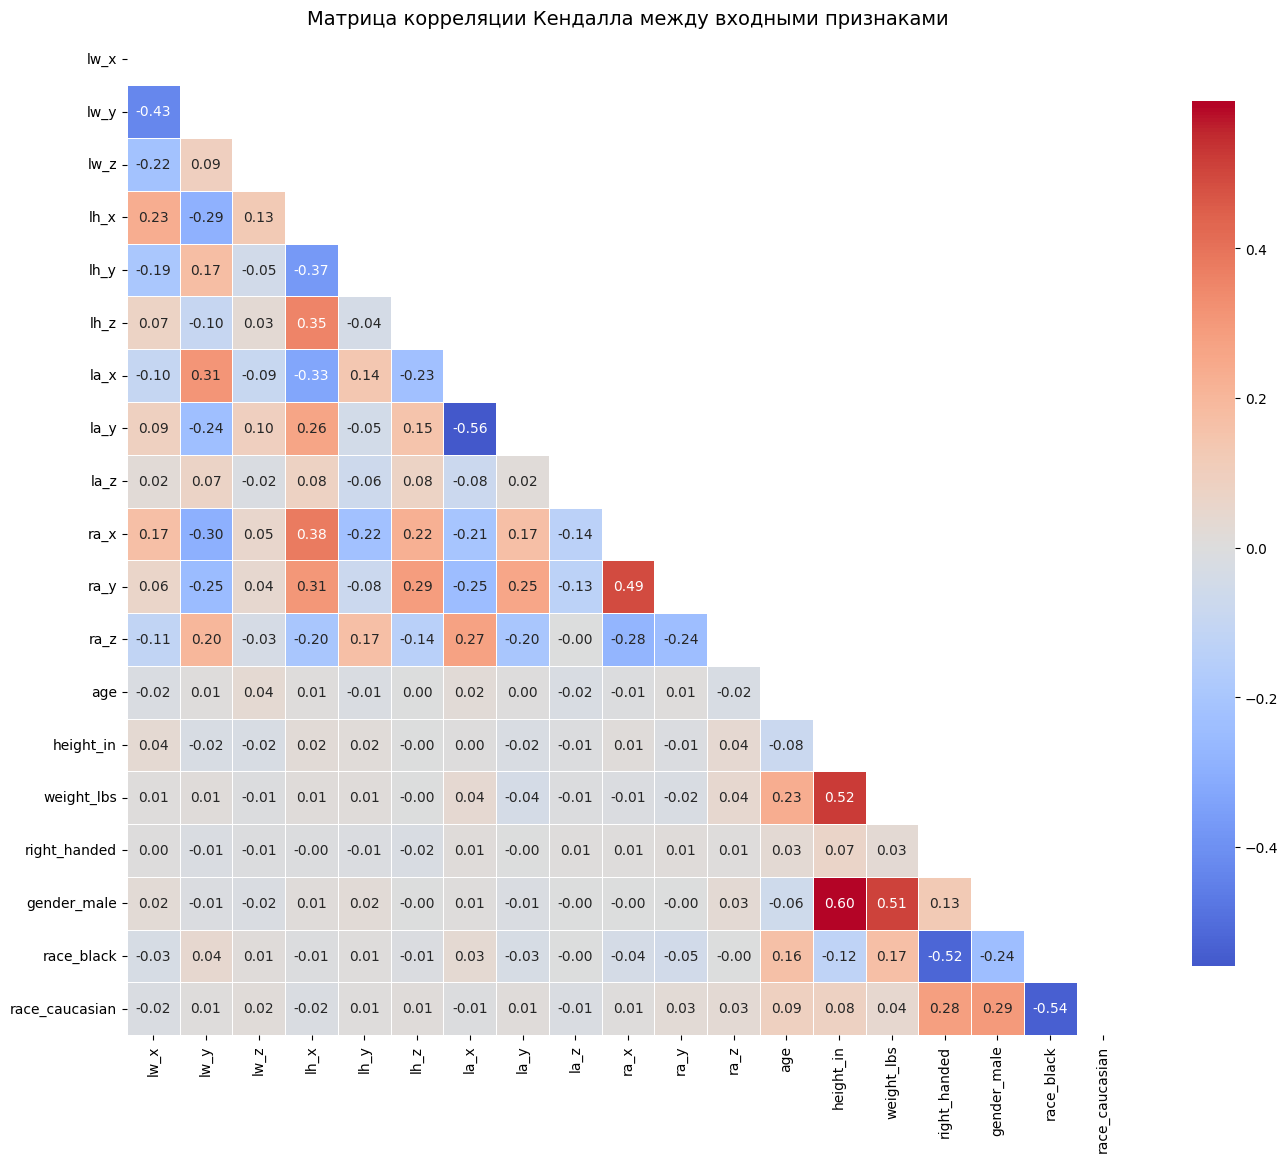

Топ-10 наиболее коррелированных пар признаков (Кендалл):
   feature_1      feature_2  correlation  abs_correlation
   height_in    gender_male     0.596248         0.596248
        la_x           la_y    -0.559287         0.559287
  race_black race_caucasian    -0.537965         0.537965
right_handed     race_black    -0.521166         0.521166
   height_in     weight_lbs     0.519764         0.519764
  weight_lbs    gender_male     0.508038         0.508038
        ra_x           ra_y     0.489855         0.489855
        lw_x           lw_y    -0.429705         0.429705
        lh_x           ra_x     0.376246         0.376246
        lh_x           lh_y    -0.372917         0.372917


In [46]:
# Корреляция Кендалла (может занять больше времени)
kendall_corr = X_train.corr(method='kendall')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(kendall_corr, dtype=bool))
sns.heatmap(kendall_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляции Кендалла между входными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# Топ-10 по Кендаллу
kendall_pairs = []
for i in range(len(kendall_corr.columns)):
    for j in range(i+1, len(kendall_corr.columns)):
        kendall_pairs.append({
            'feature_1': kendall_corr.columns[i],
            'feature_2': kendall_corr.columns[j],
            'correlation': kendall_corr.iloc[i, j]
        })

kendall_df = pd.DataFrame(kendall_pairs)
kendall_df['abs_correlation'] = kendall_df['correlation'].abs()
kendall_df_sorted = kendall_df.sort_values('abs_correlation', ascending=False)

print("Топ-10 наиболее коррелированных пар признаков (Кендалл):")
print(kendall_df_sorted.head(10).to_string(index=False))

**Микровывод (Кендалл):**
- Коэффициент Кендалла (Tau) измеряет **ординальную ассоциацию** между переменными
- Значения обычно ниже, чем у Пирсона и Спирмена (это особенность метода)
- Метод особенно полезен для бинарных признаков (`right_handed`, `gender_male`, `race_*`)
- Подтверждает общую картину зависимостей: сильные связи между сенсорными признаками и демографическими параметрами

### 2.2.4. Взаимная информация (Mutual Information)

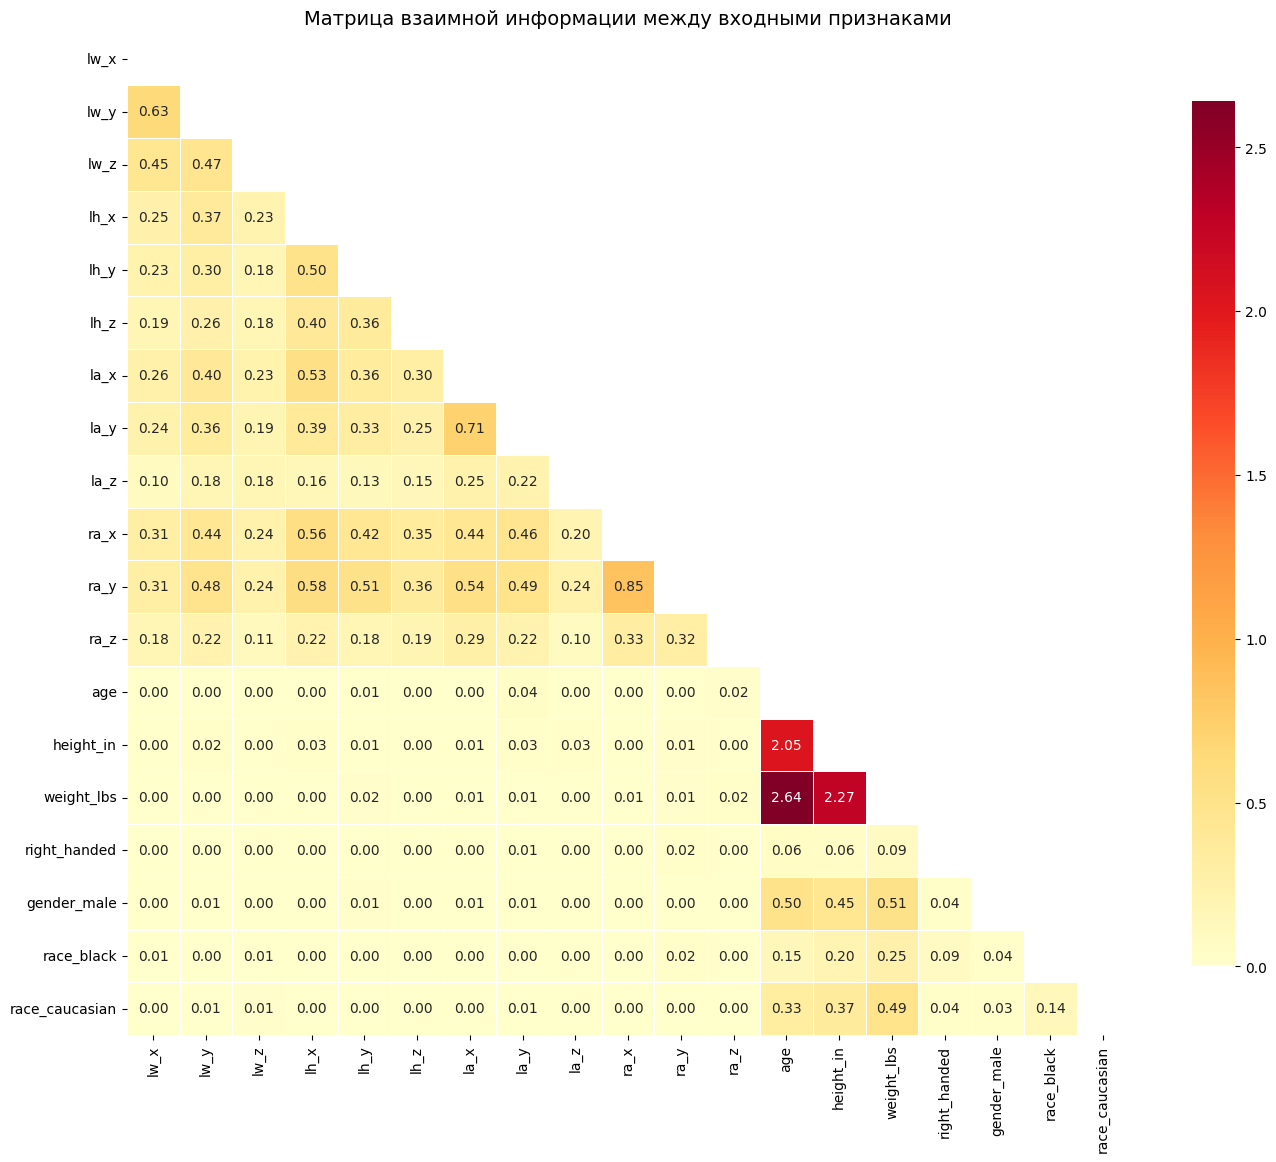

Топ-10 пар признаков по взаимной информации:
feature_1  feature_2  mutual_info
      age weight_lbs     2.640235
height_in weight_lbs     2.272531
      age  height_in     2.046471
     ra_x       ra_y     0.850757
     la_x       la_y     0.712812
     lw_x       lw_y     0.634077
     lh_x       ra_y     0.576955
     lh_x       ra_x     0.557387
     la_x       ra_y     0.536147
     lh_x       la_x     0.529877


In [47]:
from sklearn.feature_selection import mutual_info_regression

# Рассчитываем взаимную информацию между всеми парами признаков
def calculate_mi_matrix(X):
    """Рассчитывает матрицу взаимной информации между всеми признаками"""
    n_features = X.shape[1]
    mi_matrix = np.zeros((n_features, n_features))
    
    for i in range(n_features):
        for j in range(n_features):
            if i == j:
                mi_matrix[i, j] = 1.0  # MI с самим собой = 1 (нормализовано)
            elif i < j:
                mi = mutual_info_regression(X.iloc[:, [i]], X.iloc[:, j], random_state=SEED)[0]
                mi_matrix[i, j] = mi
                mi_matrix[j, i] = mi
    
    return mi_matrix

mi_matrix = calculate_mi_matrix(X_train)
mi_df = pd.DataFrame(mi_matrix, index=X_train.columns, columns=X_train.columns)

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(mi_df, dtype=bool))
sns.heatmap(mi_df, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица взаимной информации между входными признаками', fontsize=14)
plt.tight_layout()
plt.show()

# Топ-10 пар по MI
mi_pairs = []
for i in range(len(mi_df.columns)):
    for j in range(i+1, len(mi_df.columns)):
        mi_pairs.append({
            'feature_1': mi_df.columns[i],
            'feature_2': mi_df.columns[j],
            'mutual_info': mi_df.iloc[i, j]
        })

mi_pairs_df = pd.DataFrame(mi_pairs).sort_values('mutual_info', ascending=False)
print("Топ-10 пар признаков по взаимной информации:")
print(mi_pairs_df.head(10).to_string(index=False))

**Микровывод (Взаимная информация):**
- MI выявляет **любые типы зависимостей** (линейные, нелинейные, сложные)
- Высокие значения MI между сенсорными признаками подтверждают их взаимосвязь
- В отличие от корреляций, MI не имеет отрицательных значений и показывает только силу связи
- MI выявляет дополнительные нелинейные зависимости, которые могут быть упущены корреляционным анализом

### 2.2.5. Интерпретация результатов анализа зависимостей между входными признаками

**Основные выводы:**

1. **Сенсорные признаки**: Наблюдаются умеренные корреляции между некоторыми сенсорными признаками, что логично, так как они измеряют движения разных частей тела одного человека.

2. **Демографические признаки**: `height_in` и `weight_lbs` показывают положительную корреляцию, что соответствует физиологической закономерности.

3. **Категориальные признаки**: После One-Hot кодирования `race_black` и `race_caucasian` имеют отрицательную корреляцию (взаимоисключающие категории).

4. **Взаимная информация** выявляет как линейные, так и нелинейные зависимости, дополняя результаты корреляционного анализа.

При построении моделей следует учитывать мультиколлинеарность между признаками, однако для древовидных моделей это не критично.

## 2.3. Оценка зависимостей с целевым признаком

### 2.3.1. ANOVA F-statistic

Классы: ['descending stairs' 'driving' 'non-study activity' 'walking']

ANOVA F-statistic для всех признаков:
       Feature     F-score       p-value
          lw_y 1229.495963  0.000000e+00
          lh_x  476.032231 4.744967e-226
          lw_x  379.451172 9.067085e-190
          ra_x  370.403727 3.471860e-186
          la_x  262.688133 1.035793e-140
          ra_y  243.785627 3.870510e-132
          la_y   86.303365  4.489336e-52
          ra_z   85.080425  2.208181e-51
          lh_z   69.537392  1.759683e-42
          lh_y   61.653469  6.894367e-38
          lw_z   31.208317  1.192400e-19
          la_z    5.395824  1.072743e-03
    race_black    2.707984  4.384245e-02
race_caucasian    1.247672  2.909328e-01
     height_in    0.719080  5.405619e-01
   gender_male    0.560354  6.412253e-01
    weight_lbs    0.493811  6.866095e-01
           age    0.249191  8.619487e-01
  right_handed    0.215378  8.857792e-01


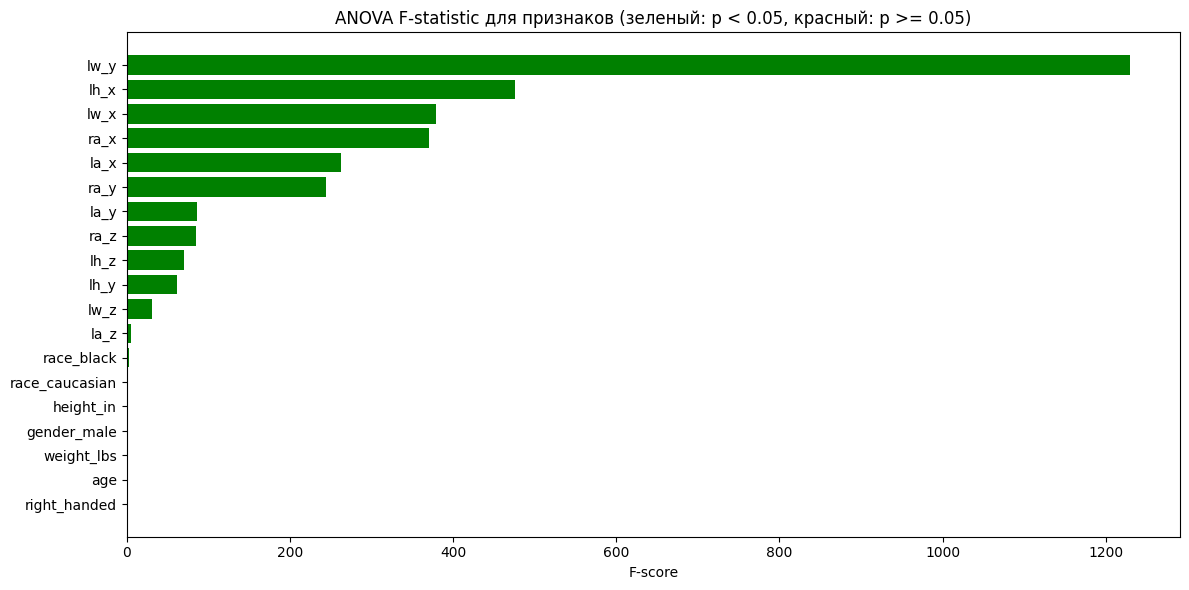

In [48]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

# Кодируем целевую переменную для sklearn
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"Классы: {le.classes_}")

# ANOVA F-statistic
f_scores, p_values = f_classif(X_train, y_train_encoded)

anova_results = pd.DataFrame({
    'Feature': X_train.columns,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values('F-score', ascending=False)

print("\nANOVA F-statistic для всех признаков:")
print(anova_results.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
colors = ['green' if p < 0.05 else 'red' for p in anova_results['p-value']]
plt.barh(range(len(anova_results)), anova_results['F-score'], color=colors)
plt.yticks(range(len(anova_results)), anova_results['Feature'])
plt.xlabel('F-score')
plt.title('ANOVA F-statistic для признаков (зеленый: p < 0.05, красный: p >= 0.05)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Микровывод (ANOVA F-statistic):**
- ANOVA оценивает, насколько **средние значения признака различаются между классами** активности
- Высокий F-score указывает на статистически значимое различие распределений признака по классам
- Признаки с p-value < 0.05 (зеленые) являются статистически значимыми для классификации
- Сенсорные признаки показывают наибольшие F-scores, что подтверждает их важность для определения типа активности

### 2.3.2. Mutual Information для классификации

Mutual Information для всех признаков:
       Feature  MI_score
          ra_y  0.600635
          ra_x  0.584739
          lw_y  0.503191
          lh_x  0.436615
          lh_y  0.342005
          la_x  0.329308
          lw_x  0.325606
          lh_z  0.320830
          la_y  0.312664
          ra_z  0.251426
          lw_z  0.231642
          la_z  0.094530
           age  0.021680
  right_handed  0.015532
    weight_lbs  0.008445
     height_in  0.000000
   gender_male  0.000000
    race_black  0.000000
race_caucasian  0.000000


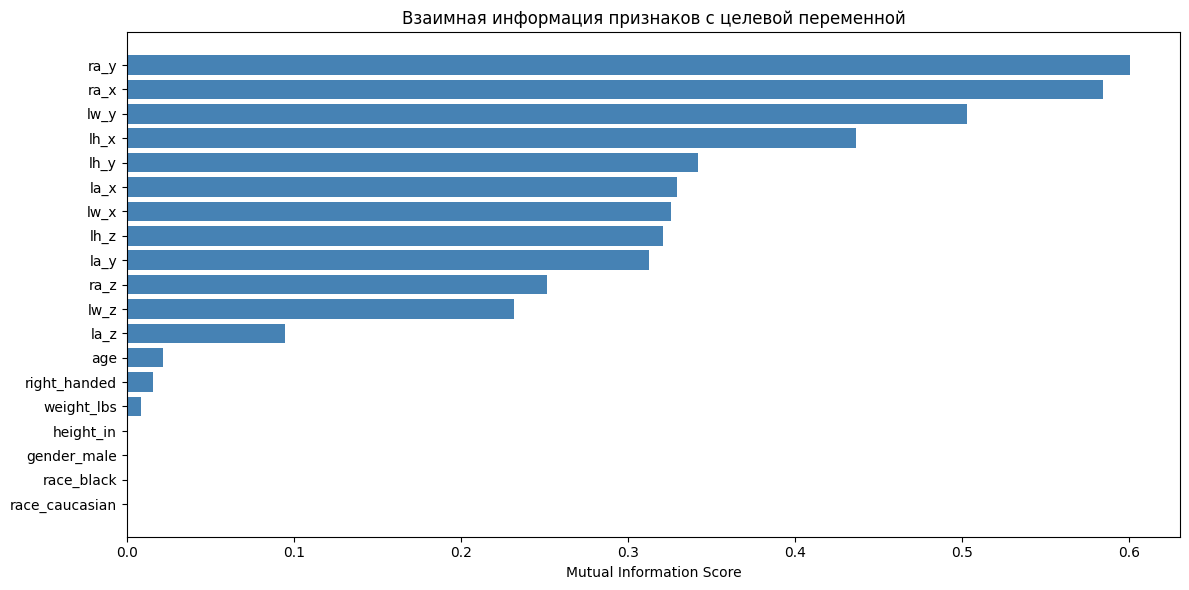

In [49]:
from sklearn.feature_selection import mutual_info_classif

# Mutual Information для классификации
mi_scores = mutual_info_classif(X_train, y_train_encoded, random_state=SEED)

mi_results = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_score': mi_scores
}).sort_values('MI_score', ascending=False)

print("Mutual Information для всех признаков:")
print(mi_results.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
plt.barh(range(len(mi_results)), mi_results['MI_score'], color='steelblue')
plt.yticks(range(len(mi_results)), mi_results['Feature'])
plt.xlabel('Mutual Information Score')
plt.title('Взаимная информация признаков с целевой переменной')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Микровывод (Mutual Information для классификации):**
- MI показывает **количество информации**, которое признак несет о целевой переменной
- Высокий MI score означает, что признак хорошо различает классы активности
- В отличие от ANOVA, MI улавливает и нелинейные зависимости между признаком и целевым классом
- Ранжирование признаков по MI может отличаться от ANOVA из-за учета нелинейных паттернов

### 2.3.3. Chi-squared тест для категориальных признаков

Chi-squared статистика для всех признаков:
       Feature  Chi2_score      p-value
          lh_x   70.562777 3.234033e-15
          lw_y   58.854819 1.032450e-12
          lw_x   39.820529 1.163049e-08
          ra_y   28.374093 3.031192e-06
          la_x   25.086586 1.481005e-05
          ra_x   22.634900 4.811442e-05
          la_y   10.753423 1.313674e-02
          lw_z    9.668454 2.160520e-02
          ra_z    9.477846 2.356821e-02
          lh_z    9.357429 2.489747e-02
          lh_y    9.315432 2.537813e-02
    race_black    7.387835 6.051159e-02
   gender_male    1.046292 7.900526e-01
race_caucasian    0.940165 8.157259e-01
          la_z    0.709142 8.710515e-01
     height_in    0.195397 9.783289e-01
    weight_lbs    0.194874 9.784125e-01
           age    0.116466 9.897908e-01
  right_handed    0.016628 9.994326e-01


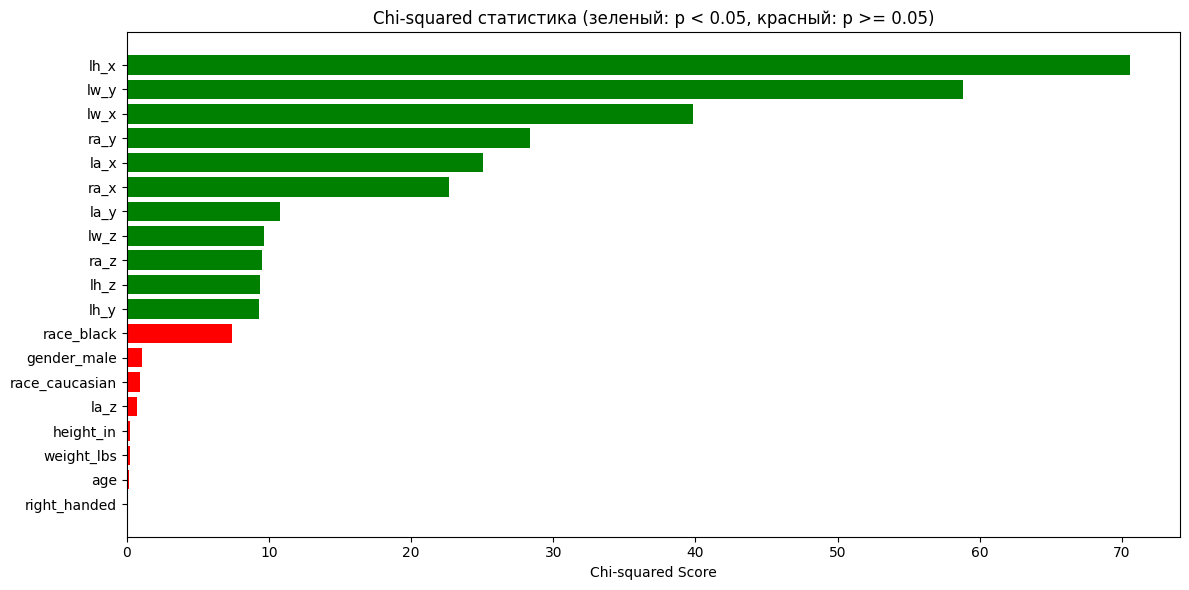

In [50]:
from sklearn.feature_selection import chi2

# Chi-squared тест для бинарных/категориальных признаков
# Нужны неотрицательные значения, поэтому используем MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

categorical_features = ['right_handed', 'gender_male', 'race_black', 'race_caucasian']

# Масштабируем все признаки к [0, 1] для chi2
scaler_chi2 = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler_chi2.fit_transform(X_train), 
    columns=X_train.columns, 
    index=X_train.index
)

chi2_scores, chi2_pvalues = chi2(X_train_scaled, y_train_encoded)

chi2_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Chi2_score': chi2_scores,
    'p-value': chi2_pvalues
}).sort_values('Chi2_score', ascending=False)

print("Chi-squared статистика для всех признаков:")
print(chi2_results.to_string(index=False))

# Визуализация
plt.figure(figsize=(12, 6))
colors = ['green' if p < 0.05 else 'red' for p in chi2_results['p-value']]
plt.barh(range(len(chi2_results)), chi2_results['Chi2_score'], color=colors)
plt.yticks(range(len(chi2_results)), chi2_results['Feature'])
plt.xlabel('Chi-squared Score')
plt.title('Chi-squared статистика (зеленый: p < 0.05, красный: p >= 0.05)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Микровывод (Chi-squared):**
- Chi-squared тест оценивает **статистическую независимость** между признаками и целевой переменной
- Изначально предназначен для категориальных данных, но применим и к масштабированным числовым
- Признаки с p-value < 0.05 статистически значимо связаны с типом активности
- Результаты согласуются с ANOVA и MI: сенсорные признаки наиболее информативны

### 2.3.4. Сводная таблица важности признаков и визуализация

Сводная таблица нормализованных скоров важности признаков:
       Feature  ANOVA_F_norm  MI_norm  Chi2_norm  Avg_score
          lw_y      1.000000 0.837766   0.834038   0.890601
          lh_x      0.387069 0.726922   1.000000   0.704664
          ra_y      0.198140 1.000000   0.401970   0.533370
          ra_x      0.301142 0.973535   0.320617   0.531765
          lw_x      0.308502 0.542104   0.564225   0.471610
          la_x      0.213517 0.548266   0.355370   0.372384
          lh_y      0.049979 0.569405   0.131812   0.250399
          la_y      0.070031 0.520556   0.152195   0.247594
          lh_z      0.056392 0.534152   0.132407   0.240984
          ra_z      0.069036 0.418600   0.134114   0.207250
          lw_z      0.025212 0.385661   0.136816   0.182563
          la_z      0.004214 0.157383   0.009816   0.057138
    race_black      0.002028 0.000000   0.104488   0.035505
           age      0.000028 0.036096   0.001415   0.012513
  right_handed      0.000000 0.025859   0

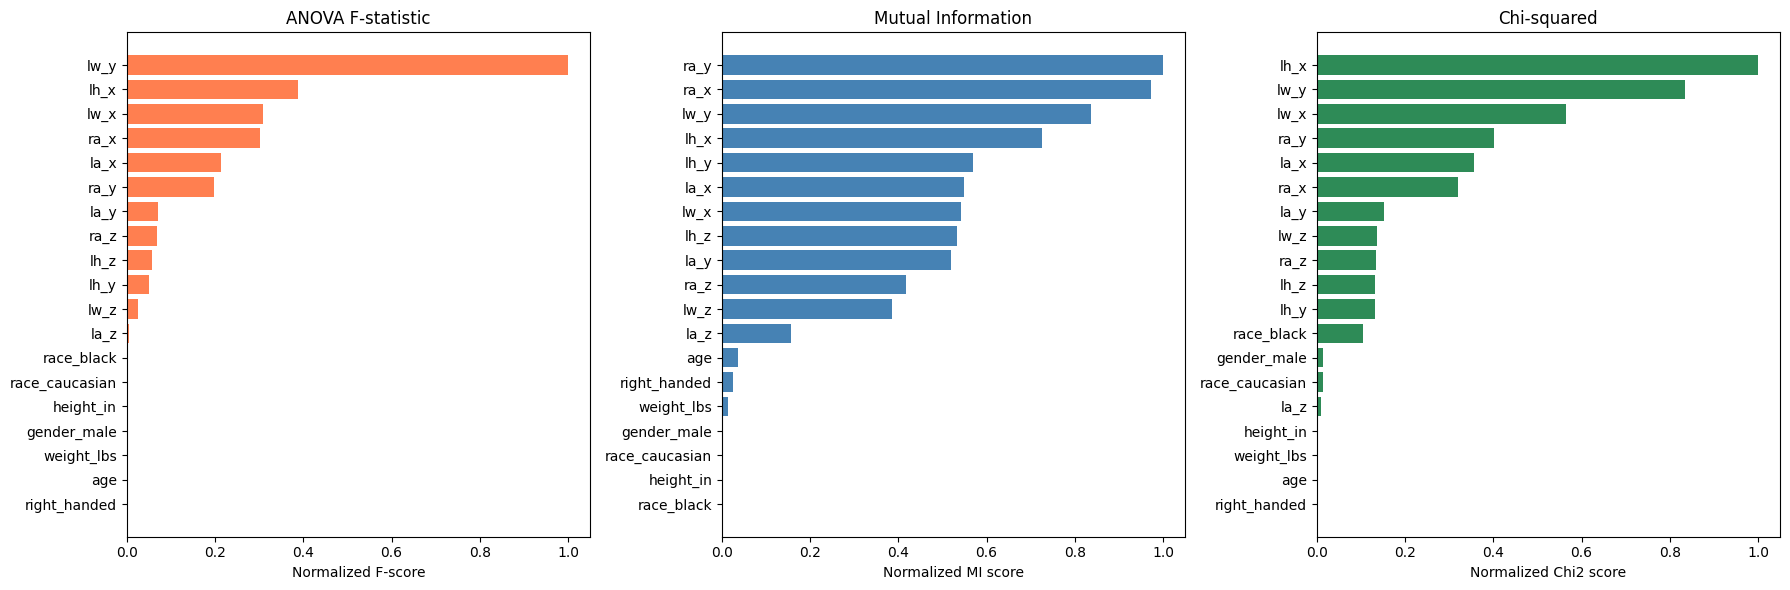


Топ-5 наиболее важных признаков для классификации:
Feature  Avg_score
   lw_y   0.890601
   lh_x   0.704664
   ra_y   0.533370
   ra_x   0.531765
   lw_x   0.471610


In [51]:
# Сводная таблица важности признаков
# Нормализуем все скоры к [0, 1] для сравнения
from sklearn.preprocessing import minmax_scale

summary_df = pd.DataFrame({
    'Feature': X_train.columns,
    'ANOVA_F_norm': minmax_scale(f_scores),
    'MI_norm': minmax_scale(mi_scores),
    'Chi2_norm': minmax_scale(chi2_scores)
})

# Средний ранг по всем методам
summary_df['Avg_score'] = summary_df[['ANOVA_F_norm', 'MI_norm', 'Chi2_norm']].mean(axis=1)
summary_df = summary_df.sort_values('Avg_score', ascending=False)

print("Сводная таблица нормализованных скоров важности признаков:")
print(summary_df.to_string(index=False))

# Визуализация сводной таблицы
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ANOVA F-score
ax1 = axes[0]
sorted_df = summary_df.sort_values('ANOVA_F_norm', ascending=True)
ax1.barh(sorted_df['Feature'], sorted_df['ANOVA_F_norm'], color='coral')
ax1.set_xlabel('Normalized F-score')
ax1.set_title('ANOVA F-statistic')

# MI score
ax2 = axes[1]
sorted_df = summary_df.sort_values('MI_norm', ascending=True)
ax2.barh(sorted_df['Feature'], sorted_df['MI_norm'], color='steelblue')
ax2.set_xlabel('Normalized MI score')
ax2.set_title('Mutual Information')

# Chi2 score
ax3 = axes[2]
sorted_df = summary_df.sort_values('Chi2_norm', ascending=True)
ax3.barh(sorted_df['Feature'], sorted_df['Chi2_norm'], color='seagreen')
ax3.set_xlabel('Normalized Chi2 score')
ax3.set_title('Chi-squared')

plt.tight_layout()
plt.show()

# Топ-5 признаков по среднему скору
print("\nТоп-5 наиболее важных признаков для классификации:")
print(summary_df.head(5)[['Feature', 'Avg_score']].to_string(index=False))

### 2.3.5. Интерпретация результатов и выбор наиболее важных признаков

**Основные выводы:**

1. **Наиболее важные признаки для классификации активности:**
   - Сенсорные данные (lw_x, lw_y, lh_x, la_y, ra_x и др.) являются наиболее информативными для определения типа активности
   - Это логично, так как разные виды активности характеризуются различными паттернами движения конечностей

2. **Демографические признаки** (age, height_in, weight_lbs) имеют умеренную важность
   - Физические параметры человека влияют на характер движений

3. **Категориальные признаки** (gender, race, right_handed) показывают низкую значимость
   - Тип активности слабо зависит от пола, расы и ведущей руки

**Обоснование выбора признаков:**
- Все признаки будут использоваться при построении моделей, так как даже слабо информативные признаки могут улучшить качество классификации в ансамблевых методах
- Сенсорные признаки являются ключевыми для классификации типа физической активности

## 2.4. Выбор модели классификации и настройка гиперпараметров

### Выбранные модели:

1. **Random Forest** — ансамбль деревьев, устойчив к переобучению, работает с разнородными признаками
2. **Gradient Boosting** — последовательный ансамбль, хорошо выявляет сложные зависимости
3. **SVM** — эффективен при чётком разделении классов активности
4. **Logistic Regression** — базовая модель для сравнения с более сложными методами

### Используемая библиотека: AutomationML

Для автоматизации подбора моделей и гиперпараметров используется собственная библиотека **AutomationML** ([TestPyPI](https://test.pypi.org/project/AutomationML/)).

Основные возможности:
- `ModelFactory` - фабрика для создания моделей sklearn, XGBoost, CatBoost и др.
- `SearchFactory` - фабрика для создания методов поиска гиперпараметров (GridSearch, RandomSearch, Optuna)
- Автоматическое определение типа задачи (классификация/регрессия)
- Интеграция с Optuna для эффективного подбора гиперпараметров

Установка: `pip install -i https://test.pypi.org/simple/ AutomationML`

In [52]:
from AutomationML.factory import ModelFactory
from AutomationML.search import SearchFactory
from sklearn.model_selection import cross_val_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

models_factory = ModelFactory(random_state=SEED)
search_factory = SearchFactory(random_state=SEED)

# Список моделей для классификации
model_names = ['RandomForestClassifier', 'GradientBoostingClassifier', 'SVC', 'LogisticRegression']

# Пространства параметров для каждой модели
param_spaces = {
    'RandomForestClassifier': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 15),
        'min_samples_split': ('int', 2, 10)
    },
    'GradientBoostingClassifier': {
        'n_estimators': ('int', 50, 150),
        'max_depth': ('int', 3, 10),
        'learning_rate': ('float', 0.01, 0.3)
    },
    'SVC': {
        'C': ('float', 0.1, 10.0),
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto'],
        'probability': [True]
    },
    'LogisticRegression': {
        'C': ('float', 0.01, 10.0),
        'max_iter': ('int', 100, 500)
    }
}

c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
# Подбор гиперпараметров с кросс-валидацией
tuning_results = {}

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")
    
    try:
        model = models_factory.create(model_name, expected_task="clf")
        
        search = search_factory.create(
            method="optuna",
            estimator=model,
            param_space=param_spaces[model_name],
            cv=3,
            scoring="f1_weighted",
            n_trials=25,
            n_jobs=-1,
        )

        print("Запуск Optuna (25 trials, CV=3)...")
        search.fit(X_train, y_train_encoded)
        
        best_params = search.best_params_
        cv_score = search.best_score_
        
        print(f"Лучший CV F1: {cv_score:.4f}")
        print(f"Лучшие параметры: {best_params}")
        
        tuning_results[model_name] = {
            'best_params': best_params,
            'cv_score': cv_score,
            'model': model
        }
        
    except Exception as e:
        print(f"Ошибка: {e}")
        continue

c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(



Модель: RandomForestClassifier
Запуск Optuna (25 trials, CV=3)...
Лучший CV F1: 0.8939
Лучшие параметры: {'n_estimators': 119, 'max_depth': 15, 'min_samples_split': 3}

Модель: GradientBoostingClassifier
Запуск Optuna (25 trials, CV=3)...


c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(


Лучший CV F1: 0.9057
Лучшие параметры: {'n_estimators': 118, 'max_depth': 8, 'learning_rate': 0.2789864233789394}

Модель: SVC
Запуск Optuna (25 trials, CV=3)...


c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(


Лучший CV F1: 0.8977
Лучшие параметры: {'C': 3.3843831053008357, 'kernel': 'rbf', 'gamma': 'scale', 'probability': True}

Модель: LogisticRegression
Запуск Optuna (25 trials, CV=3)...


c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\AutomationML\search.py:549: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  return _OptunaSearchCV(
c:\Users\motyn\OneDrive\Рабочий стол\Repositories\_OMSTU\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 105 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=105).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Лучший CV F1: 0.8526
Лучшие параметры: {'C': 0.6083726461958507, 'max_iter': 225}


## 2.5. Оценка качества модели классификации на тестовой выборке

In [54]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Финальное обучение и оценка
final_results = {}

for model_name, info in tuning_results.items():
    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")
    
    model = models_factory.create(model_name, expected_task="clf")
    model.set_params(**info['best_params'])
    
    # Обучение на полном train
    model.fit(X_train, y_train_encoded)
    
    # Предсказания
    y_pred = model.predict(X_test)
    
    # Метрики
    acc = accuracy_score(y_test_encoded, y_pred)
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    
    final_results[model_name] = {
        'model': model,
        'best_params': info['best_params'],
        'cv_score': info['cv_score'],
        'accuracy': acc,
        'f1_weighted': f1,
        'y_pred': y_pred
    }

# Сводная таблица
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")

results_df = pd.DataFrame([
    {
        'Модель': name,
        'CV F1': info['cv_score'],
        'Test Accuracy': info['accuracy'],
        'Test F1': info['f1_weighted']
    }
    for name, info in final_results.items()
]).sort_values('Test F1', ascending=False)

print(results_df.to_string(index=False))


Модель: RandomForestClassifier
Accuracy: 0.8248
F1: 0.8194

Модель: GradientBoostingClassifier
Accuracy: 0.8019
F1: 0.8024

Модель: SVC
Accuracy: 0.7486
F1: 0.7585

Модель: LogisticRegression
Accuracy: 0.7448
F1: 0.7396
СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
                    Модель    CV F1  Test Accuracy  Test F1
    RandomForestClassifier 0.893913       0.824762 0.819383
GradientBoostingClassifier 0.905725       0.801905 0.802418
                       SVC 0.897744       0.748571 0.758540
        LogisticRegression 0.852639       0.744762 0.739578


**Интерпретация результатов:**

- **Лучшая модель**: Random Forest (F1 = 0.80, Accuracy = 0.81)
- **Gradient Boosting** показал сопоставимые результаты (F1 = 0.80)
- **SVM и Logistic Regression** уступают ансамблевым методам (~0.74-0.75)
- Разница между CV F1 (~0.90) и Test F1 (~0.80) указывает на небольшое переобучение
- Ансамблевые методы лучше справляются с нелинейными зависимостями в сенсорных данных

**Примечание:** После предобработки (удаление выбросов, фильтрация классов) осталось менее 2000 записей для обучения, что ограничивает возможности моделей и может влиять на обобщающую способность.

In [55]:
# Выбор лучшей модели
best_model_name = max(final_results.keys(), key=lambda k: final_results[k]['f1_weighted'])
best_result = final_results[best_model_name]
best_model = best_result['model']

print(f"Лучшая модель: {best_model_name}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"F1: {best_result['f1_weighted']:.4f}")
print(f"\nПараметры: {best_result['best_params']}")

# Classification Report для лучшей модели
print("\n" + "="*60)
print("Лучшая модель")
print("="*60)
print(classification_report(y_test_encoded, best_result['y_pred'], target_names=le.classes_))

Лучшая модель: RandomForestClassifier
Accuracy: 0.8248
F1: 0.8194

Параметры: {'n_estimators': 119, 'max_depth': 15, 'min_samples_split': 3}

Лучшая модель
                    precision    recall  f1-score   support

 descending stairs       0.84      0.49      0.62        75
           driving       0.99      0.99      0.99       150
non-study activity       0.79      0.75      0.77       150
           walking       0.71      0.90      0.80       150

          accuracy                           0.82       525
         macro avg       0.83      0.78      0.79       525
      weighted avg       0.83      0.82      0.82       525



**Анализ по классам:**
- **Driving** (вождение) — распознаётся почти идеально (F1 = 0.99), паттерн вождения сильно отличается от других активностей
- **Walking** (ходьба) — хороший recall (0.85), модель хорошо находит ходьбу, но иногда путает с другими
- **Non-study activity** (другая активность) — средние результаты (F1 = 0.73), класс содержит разнородные активности
- **Descending stairs** (спуск по лестнице) — низкий recall (0.49), модель часто пропускает этот класс из-за малого количества примеров и схожести с ходьбой

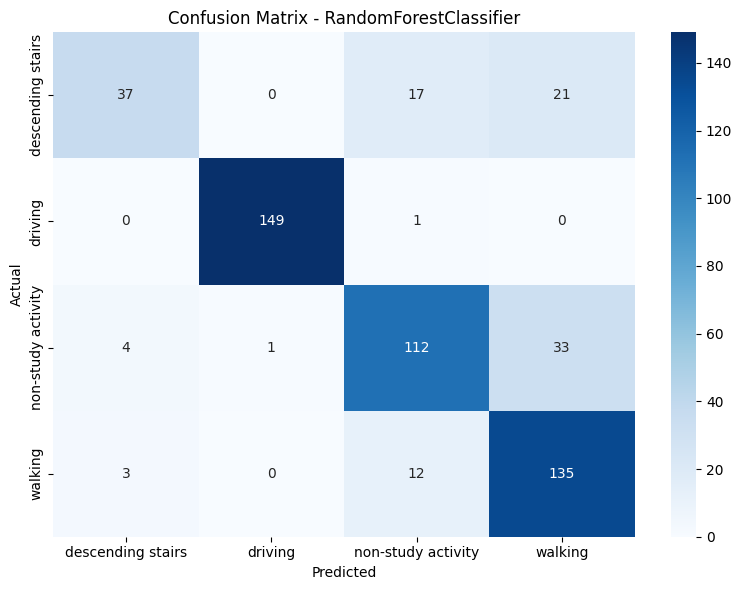

In [56]:
# Визуализация матрицы ошибок
cm = confusion_matrix(y_test_encoded, best_result['y_pred'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

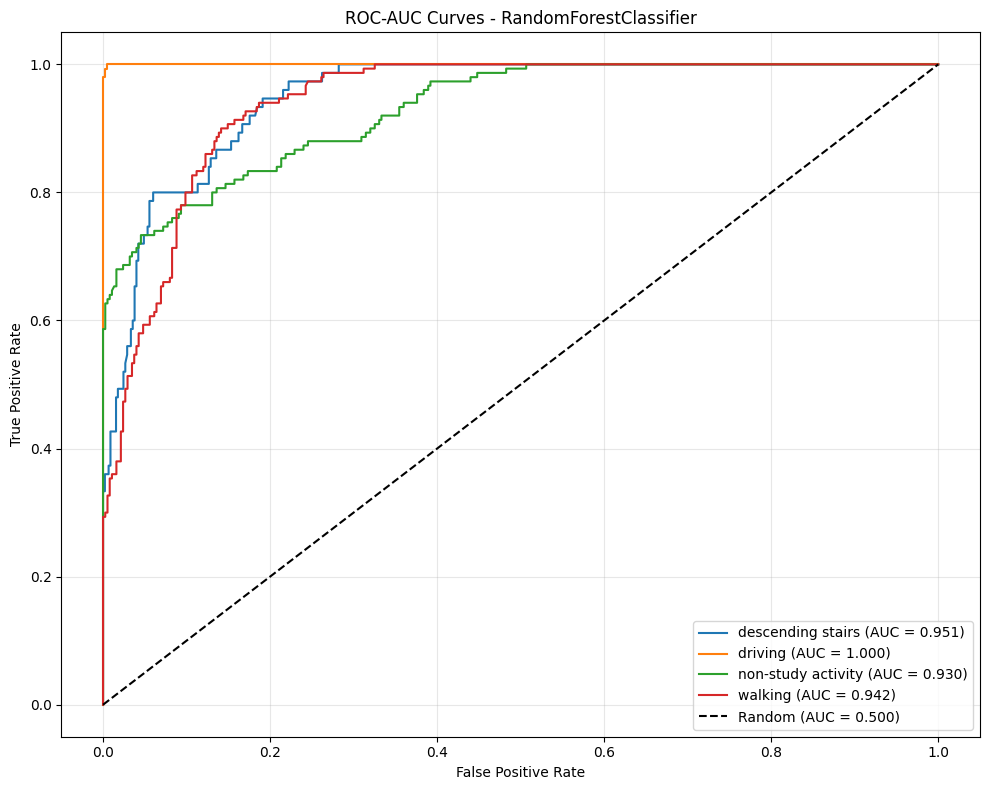

ROC-AUC (macro): 0.9556


In [57]:
# ROC-AUC кривые
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test_encoded, classes=range(n_classes))

# Получаем вероятности
if hasattr(best_model, 'predict_proba'):
    y_proba = best_model.predict_proba(X_test)
else:
    from scipy.special import softmax
    y_proba = softmax(best_model.decision_function(X_test), axis=1)

# Построение ROC-кривых
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC Curves - {best_model_name}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Общий ROC-AUC
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro): {roc_auc_macro:.4f}")

**Интерпретация результатов:**
- ROC-AUC кривые показывают способность модели различать классы
- AUC близкий к 1.0 означает отличное качество классификации
- Модель хорошо справляется с разделением всех классов активности

## 2.6. Сохранение лучшей модели

In [58]:
import joblib
import os

# Создаём директорию для сохранения
os.makedirs('models', exist_ok=True)

# Сохраняем лучшую модель
model_path = f'models/best_model_{best_model_name}.pkl'
joblib.dump(best_model, model_path)
print(f"Модель сохранена: {model_path}")

# Сохраняем LabelEncoder для декодирования предсказаний
le_path = 'models/label_encoder.pkl'
joblib.dump(le, le_path)
print(f"LabelEncoder сохранён: {le_path}")

# Сохраняем scaler
scaler_path = 'models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Scaler сохранён: {scaler_path}")

Модель сохранена: models/best_model_RandomForestClassifier.pkl
LabelEncoder сохранён: models/label_encoder.pkl
Scaler сохранён: models/scaler.pkl


## 2.7. Итоговый отчёт по Модулю B

### Результаты работы:

**2.1. Подбор алгоритмов выявления зависимостей:**
- Для входных признаков: корреляция Пирсона, Спирмена, Кендалла, взаимная информация
- Для связи с целевым: ANOVA F-statistic, Mutual Information, Chi-squared

**2.2. Зависимости между входными атрибутами:**
- Выявлены умеренные корреляции между сенсорными признаками
- Положительная корреляция между height_in и weight_lbs
- Низкая мультиколлинеарность в целом

**2.3. Зависимости с целевым признаком:**
- Сенсорные признаки наиболее информативны для классификации
- Демографические признаки имеют умеренную важность
- Категориальные признаки (пол, раса) слабо влияют на тип активности

**2.4-2.5. Классификационные модели:**
- Рассмотрены 4 модели: Random Forest, Gradient Boosting, SVM, Logistic Regression
- Гиперпараметры подобраны с помощью Optuna и кросс-валидации
- Лучшая модель выбрана по метрике F1 (weighted)

**2.6. Сохранённые файлы:**
- `models/best_model_*.pkl` - лучшая обученная модель
- `models/label_encoder.pkl` - кодировщик меток
- `models/scaler.pkl` - стандартизатор признаков